# Driven Anharmonic Oscillator

This program solves the differential equation 
$$
 \partial_t W = \{H,W\} + \gamma\{H, \{H,W\}\} -4 \Gamma (H^2 - \langle H^2 \rangle)W - \hbar^2 B x\, \frac{\partial^3W}{\partial p^3}
$$
with $\hat{H} = \frac{\hat{p}^2}{2m} - A\hat{x}^2 + B\hat{x}^4+ \Lambda \hat{x} \cos{(\omega_d t)}\,.$

In [1]:
using FFTW, Interpolations, LinearAlgebra, Plots
gr()

# ------------------ Parameters ------------------
function decoherence_PDE(use_hbar, γ, Γ)
    m = 1.0
    A = 1.0
    B = 0.1
    Λ = 0.2
    ω = 1.0
    ħ = 0.5
    #use_hbar = true

    x0 = 2.19
    p0 = 0.0
    σx = 0.5
    σp = ħ / (2σx)

    Nx, Np = 256, 256
    xmax, pmax = 6.0, 6.0
    x = range(-xmax, xmax; length=Nx)
    p = range(-pmax, pmax; length=Np)
    dx, dp = step(x), step(p)
    X = repeat(x, 1, Np)
    P = repeat(p', Nx, 1)

    dt = 0.002
    Tfinal = 10.0
    nsteps = Int(round(Tfinal/dt))
    output_every = 50

    # Diffusion control
    use_gamma = true   # diffusion strength

    # ------------------ Initial Wigner ------------------
    W = (1/(π*ħ)) .* exp.(-((X .- x0).^2)/(2σx^2) .- ((P .- p0).^2)/(2σp^2))
    W ./= sum(W) * dx * dp

    # ------------------ Potential ------------------
    V(x,t) = -A*x^2 + B*x^4 + Λ*x*cos(ω*t)
    V′(x,t) = -2A*x + 4B*x^3 + Λ*cos(ω*t)
    V″(x,t) = -2A + 12B*x^2

    # ------------------ Helpers ------------------
    function interpolate_bilinear(W::Matrix, xgrid::AbstractVector, pgrid::AbstractVector)
        interpolate((xgrid, pgrid), W, Gridded(Linear()))
    end

    function classical_step(W, t, τ)
        itp = interpolate_bilinear(W, x, p)
        xback = @. X - (P/m)*τ
        pback = @. P + V′(X, t)*τ
        out = similar(W)
        for i in eachindex(x), j in eachindex(p)
            xb, pb = xback[i,j], pback[i,j]
            if xb < first(x) || xb > last(x) || pb < first(p) || pb > last(p)
                out[i,j] = 0.0
            else
                out[i,j] = itp(xb, pb)
            end
        end
        return out
    end

    # Quantum step via FFT in p-space
    kp = 2π .* fftfreq(Np, 1/dp)
    ik3 = (im .* kp).^3

    function quantum_step(W, τ)
        Ŵ = fft(W, 2)
        if use_hbar
            mult = @. exp(- (ħ^2) * B * x * ik3' * τ)
        else
            mult = ones(size(Ŵ))
        end
        Ŵ .*= mult
        return real(ifft(Ŵ, 2))
    end

    # Smooth absorbing mask
    function make_mask(coord, coord_max; start_frac=0.85, width_frac=0.08)
        start = start_frac * coord_max
        width = width_frac * coord_max
        mask = ones(length(coord))
        for i in eachindex(coord)
            val = abs(coord[i])
            if val > start
                mask[i] = exp(-((val - start)/width)^2)
            end
        end
        return mask
    end

    maskx = make_mask(x, xmax)
    maskp = make_mask(p, pmax)
    mask2d = maskx * maskp'

    # Diagnostics
    function diagnostics(W, t)
        norm = sum(W)*dx*dp
        ρx = sum(W, dims=2)*dp
        ρp = sum(W, dims=1)*dx
        xmean = sum(x .* ρx[:,1])*dx
        pmean = sum(p .* ρp[1,:])*dp
        KE = 0.5*sum((P.^2/m).*W)*dx*dp
        PE = sum(V.(X,t).*W)*dx*dp
        E = KE + PE
        W_neg = minimum(W)
        total_neg_area = sum(abs.(W[W .< 0])) * dx * dp
        total_log_neg_area = log(sum(abs.(W))*dx*dp)
        return (t=t, norm=norm, xmean=xmean, pmean=pmean, E=E, W_neg = W_neg, total_neg_area = total_neg_area, total_log_neg_area = total_log_neg_area)
    end

    # --- Parameters you can tune ---
                # your gamma (choose appropriate)
    exponent_threshold = 1.0 # target max magnitude per substep (≈|exponent| <= 1)
    exponent_clamp = 60.0    # hard clamp to avoid overflow in exp

    # --- Dissipator step (in-place) ---
    function dissipator_step!(W::AbstractMatrix, t::Float64, τ::Float64;
                            Γ::Float64=Γ, dx::Float64=dx, dp::Float64=dp,
                            exponent_threshold::Float64=exponent_threshold,
                            exponent_clamp::Float64=exponent_clamp)

        # compute H and H^2 on grid (same time t used for V as elsewhere)
        H = @. (P.^2)/(2m) + V(X, t)
        H2 = @. H^2

        # compute global mean <H^2> with current W
        H2mean = sum(H2 .* W) * dx * dp

        # compute maximum magnitude of exponent for whole grid for full τ
        max_exponent = maximum(abs.(-4.0*Γ*(H2 .- H2mean)*τ))

        # choose number of substeps to keep per-substep exponent <= threshold
        nsub = max(1, ceil(Int, max_exponent / exponent_threshold))

        τsub = τ / nsub
        prev_norm = sum(W) * dx * dp  # store norm to restore later

        for s in 1:nsub
            # recompute exponent for substep using same H2mean (frozen for substep series)
            expo = @. -4.0*Γ*(H2 .- H2mean)*τsub

            # clamp to avoid overflow; choice of clamp depends on problem
            @. expo = clamp(expo, -exponent_clamp, exponent_clamp)

            # apply multiplicative factor
            @. W = W * exp(expo)
        end

        # renormalize to preserve mass (the continuous equation conserves it)
        W ./= (sum(W)*dx*dp) / prev_norm

        return nothing
    end

    # ------------------ ADI Diffusion Step ------------------
    """
    ADI semi-implicit step for diffusion-like operator:
        W_t = γ [ (p/m)^2 ∂_x^2 W + (V'(x,t))^2 ∂_p^2 W ]
    Cross terms are neglected for stability & speed.
    """
    function diffusion_step_ADI!(W, t, γ, dt)
        Nx, Np = size(W)
        if γ == 0.0
            return W
        end

        # Compute coefficients
        Vp = @. V′(x, t)
        P2 = (p.^2) / m^2
        αx = @. 0.5 * dt * γ * P2 / dx^2
        αp = @. 0.5 * dt * γ * (Vp^2) / dp^2

        # --- X-direction implicit step ---
        Wtmp = similar(W)
        for j in 1:Np
            # Build tridiagonal system along x for fixed p_j
            a = -αx
            b = 1 .+ 2αx
            c = -αx
            rhs = W[:, j]
            Wtmp[:, j] = Tridiagonal(a[2:end], b, c[1:end-1]) \ rhs
        end

        # --- P-direction implicit step ---
        Wnew = similar(W)
        for i in 1:Nx
            a = -αp
            b = 1 .+ 2αp
            c = -αp
            rhs = Wtmp[i, :]
            Wnew[i, :] = (Tridiagonal(a[2:end], b, c[1:end-1]) \ rhs)'
        end

        return Wnew
    end

    # ------------------ Time Evolution ------------------
    t = 0.0
    Wframes = [copy(W)]
    diagnostics_list = [diagnostics(W,t)]

    for step in 1:nsteps
        # Classical → Quantum → Classical (Strang)
        W = classical_step(W, t, dt/2)

        # dissipator half-step
        dissipator_step!(W, t, dt/2; Γ=Γ, dx=dx, dp=dp)

        if use_gamma
            W = diffusion_step_ADI!(W, t, γ, dt/2)
        end

        W .= quantum_step(W, dt)

        if use_gamma
            W = diffusion_step_ADI!(W, t+dt/2, γ, dt/2)
        end

        # dissipator half-step (use t+dt since we've advanced in time)
        dissipator_step!(W, t+dt, dt/2; Γ=Γ, dx=dx, dp=dp)

        W = classical_step(W, t+dt, dt/2)

        # Absorbing mask
        W .*= mask2d

        # Renormalization
        if step % 50 == 0
            W ./= sum(W) * dx * dp
        end

        t += dt
        if step % output_every == 0 || step == nsteps
            push!(diagnostics_list, diagnostics(W,t))
            push!(Wframes, copy(W))
        end
    end

    # ------------------ Diagnostics Summary ------------------
    ts = [d.t for d in diagnostics_list]
    norms = [d.norm for d in diagnostics_list]
    xmeans = [d.xmean for d in diagnostics_list]
    pmeans = [d.pmean for d in diagnostics_list]
    Es = [d.E for d in diagnostics_list]
    W_min = [d.W_neg for d in diagnostics_list]
    total_neg_area = [d.total_neg_area for d in diagnostics_list]
    total_log_neg_area = [d.total_log_neg_area for d in diagnostics_list]

    return ts, norms, xmeans, pmeans, Es, W_min, total_neg_area, total_log_neg_area
end

decoherence_PDE (generic function with 1 method)

# Wigner negativity Plot

In [2]:
#This cell computes the mean values for different prameter values
hbar, gamma, Gamma= 0.5, 0.05, 0.1 #0.05, 0.1

test_all_off = decoherence_PDE(false, 0.0, 0.0);
test_hbar_on = decoherence_PDE(true, 0.0, 0.0);
test_gamma_on = decoherence_PDE(true, gamma, 0.0);
test_gamma_on_Gamma_on = decoherence_PDE(true, gamma, Gamma);

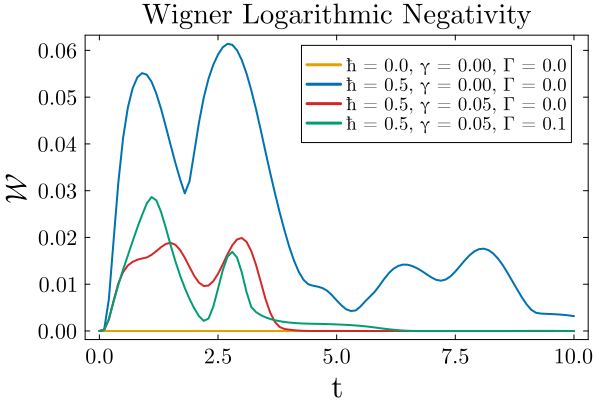

In [3]:
using LaTeXStrings
ts = test_all_off[1]

colors = ["#E69F00","#0072B2", "#D62728", "#009E73"]
#["#0072B2", "#E69F00", "#009E73", "#D62728"] #"#CC79A7"]
 
total_neg_area, total_log_neg_area = test_all_off[7], test_all_off[8]
total_neg_area_1, total_log_neg_area_1 = test_hbar_on[7], test_hbar_on[8]
total_neg_area_2, total_log_neg_area_2 = test_gamma_on[7], test_gamma_on[8] 
total_neg_area_3, total_log_neg_area_3 = test_gamma_on_Gamma_on[7], test_gamma_on_Gamma_on[8]  

default(titlefontsize=18, guidefontsize=16, tickfontsize=14, legendfontsize=12, labelfontsize = 20)
plt = plot(ts, total_log_neg_area,label = "ħ = 0.0, γ = 0.00, Γ = 0.0", xlabel = "t", ylabel = L"\mathcal{W}", frame=:box,grid=false, color=colors[1], lw = 2.0)
plot!(ts, total_log_neg_area_1,label = "ħ = 0.5, γ = 0.00, Γ = 0.0", fontfamily="Computer Modern", title = "Wigner Logarithmic Negativity", color=colors[2], lw = 2.0)
plot!(ts, total_log_neg_area_2,label = "ħ = 0.5, γ = 0.05, Γ = 0.0", color=colors[3], lw = 2.0)
plot!(ts, total_log_neg_area_3,label = "ħ = 0.5, γ = 0.05, Γ = 0.1", color=colors[4], lw = 2.0)

display(plt)
#savefig(plt, "Wigner_function_log_negative.pdf")


In [4]:
#This cell calculates when the Wigner function negativity goes to zero.
function first_zero_time(time::Vector{<:Real}, values::Vector{<:Real})
    @assert length(time) == length(values) "time and values must have the same length"
    ans = 12.0
    for (t, v) in zip(time[2:end], values[2:end])
        if v == 0.0
            ans = t
            break
        end
    end
    return ans 
end


first_zero_time (generic function with 1 method)

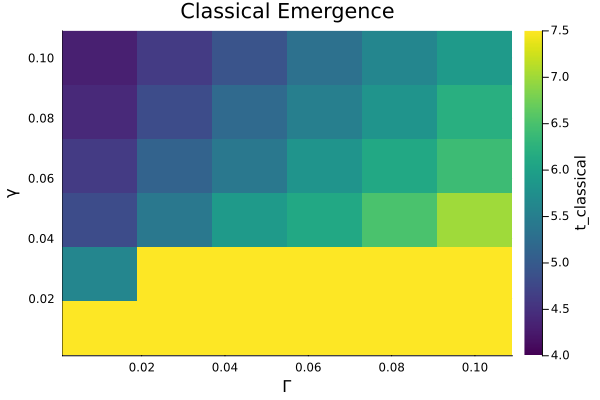

In [ ]:
#This cell plots the time of classical emergence for different parameter values
using Base.Threads
using Plots

# ------------------------------------------------------------
# Parallel parameter sweep using multi-threading
# ------------------------------------------------------------
function run_parallel_sweep(decoherence_PDE;
                            γ_range = range(0.01, 0.1, length=6),
                            Γ_range = range(0.01, 0.1, length=6))

    γ_vals = collect(γ_range)
    Γ_vals = collect(Γ_range)
    Z = zeros(length(γ_vals), length(Γ_vals))

    @threads for i in eachindex(γ_vals)
        for j in eachindex(Γ_vals)
            γ, Γ = γ_vals[i], Γ_vals[j]
            ts, norms, xmeans, pmeans, Es, W_min, total_neg_win = decoherence_PDE(true, γ, Γ)
            Z[i, j] = first_zero_time(ts, total_neg_win)  # Example metric (replace as needed)
        end
    end

    return γ_vals, Γ_vals, Z
end


γ_range, Γ_range, Z = run_parallel_sweep(decoherence_PDE) #calculate the first zero time


heatmap(Γ_range, γ_range, Z;
    xlabel="Γ",
    ylabel="γ",
    clim = (4,7.5),
    title="Classical Emergence",
    colorbar_title="t_classical",
    c=:viridis)